In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.lines import Line2D

from lo_tools import Lfun, zrfun, zfun
Ldir = Lfun.Lstart()

In [ ]:
#folder = Path("../../LO_roms/ae0_tgrdnt_xa0/f2020.01.05/")
folder = Path("../../LO_roms/ae0_tgrdnt_xa0/f2020.01.12/")
flist = sorted(folder.glob("ocean_his_*.nc"))

ds = xr.open_mfdataset(flist, combine="by_coords")

# 24-hr mean
ds24 = ds.mean(dim="ocean_time")
print(ds24)

/tmp/ipykernel_396473/2075415169.py:5: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(flist, combine="by_coords")


<xarray.Dataset> Size: 137MB
Dimensions:         (tracer: 2, boundary: 4, s_rho: 30, s_w: 31, eta_rho: 386,
                     xi_rho: 348, eta_u: 386, xi_u: 347, eta_v: 385, xi_v: 348,
                     eta_psi: 385, xi_psi: 347)
Coordinates:
  * s_rho           (s_rho) float64 240B -0.9833 -0.95 ... -0.05 -0.01667
  * s_w             (s_w) float64 248B -1.0 -0.9667 -0.9333 ... -0.03333 0.0
    lon_rho         (eta_rho, xi_rho) float64 1MB dask.array<chunksize=(386, 348), meta=np.ndarray>
    lat_rho         (eta_rho, xi_rho) float64 1MB dask.array<chunksize=(386, 348), meta=np.ndarray>
    lon_u           (eta_u, xi_u) float64 1MB dask.array<chunksize=(386, 347), meta=np.ndarray>
    lat_u           (eta_u, xi_u) float64 1MB dask.array<chunksize=(386, 347), meta=np.ndarray>
    lon_v           (eta_v, xi_v) float64 1MB dask.array<chunksize=(385, 348), meta=np.ndarray>
    lat_v           (eta_v, xi_v) float64 1MB dask.array<chunksize=(385, 348), meta=np.ndarray>
    lon_psi     

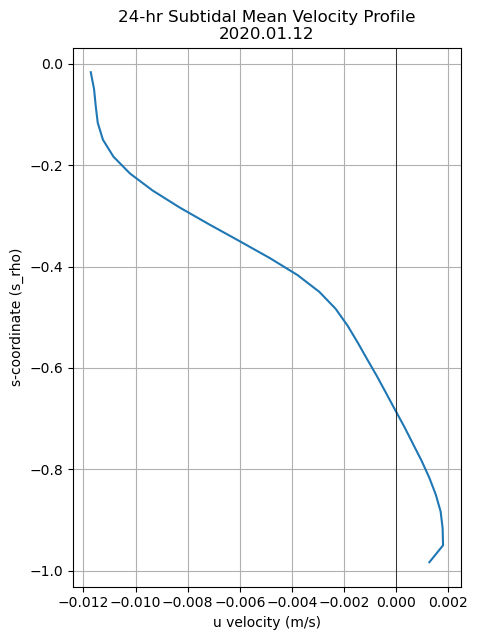

In [35]:
u_prof = ds24.u.mean(dim=("eta_u", "xi_u"))

plt.figure(figsize=(5,7))

plt.plot(u_prof.values, ds24.s_rho.values, label="u")

plt.axvline(0, color="k", lw=0.5)
plt.xlabel("u velocity (m/s)")
plt.ylabel("s-coordinate (s_rho)")
plt.title("24-hr Subtidal Mean Velocity Profile\n2020.01.12")
plt.grid(True)

plt.show()

/tmp/ipykernel_396473/4133245883.py:30: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(flist, combine="by_coords")
/tmp/ipykernel_396473/4133245883.py:30: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(flist, combine="by_coords")
/tmp/ipykernel_396473/4133245883.py:30

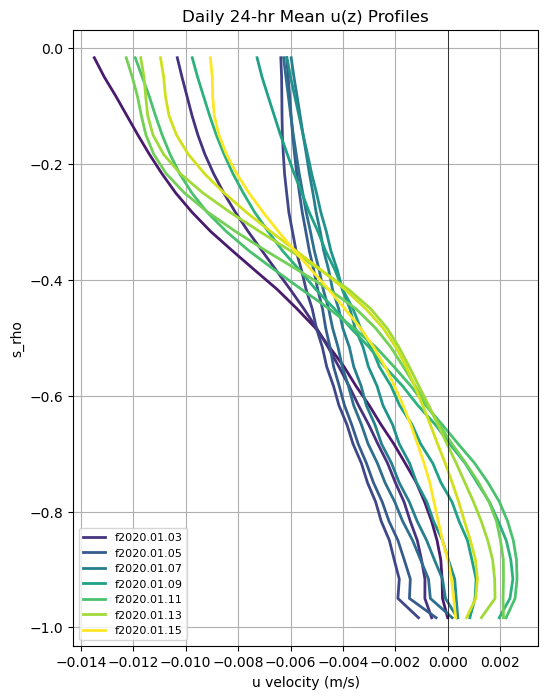

In [ ]:
# average over domain
base_dir = Path("../../LO_roms/ae0_tgrdnt_xa0/")
day_folders = sorted(base_dir.glob("f2020.01.*"))

# viridis colormap setup
cmap = cm.viridis
norm = colors.Normalize(vmin=0, vmax=len(day_folders)-1)

plt.figure(figsize=(6,8))

handles = []
labels = []

for i, folder in enumerate(day_folders):
    
    if folder.name == "f2020.01.01":
        continue

    flist = sorted(folder.glob("ocean_his_*.nc"))
    if len(flist) == 0:
        continue

    ds = xr.open_mfdataset(flist, combine="by_coords")
    ds24 = ds.mean(dim="ocean_time")

    # domain mean u profile
    u_prof = ds24.u.mean(dim=("eta_u", "xi_u"))

    col = cmap(norm(i))

    plt.plot(u_prof.values, ds24.s_rho.values, color=col, lw=2)

    # add to legend 
    if i % 2 == 0:
        handles.append(Line2D([0], [0], color=col, lw=2))
        labels.append(folder.name)

    ds.close()

plt.axvline(0, color='k', lw=0.5)
plt.xlabel("u velocity (m/s)")
plt.ylabel("s_rho")
plt.title("Daily 24-hr Mean u(z) Profiles")
plt.grid(True)

plt.legend(handles, labels, fontsize=8, loc="best")
plt.show()

In [38]:
print("eta_u:", 0, "to", ds.dims["eta_u"] - 1)
print("xi_u :", 0, "to", ds.dims["xi_u"] - 1)

eta_u: 0 to 385
xi_u : 0 to 346


/tmp/ipykernel_396473/4158646253.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("eta_u:", 0, "to", ds.dims["eta_u"] - 1)
/tmp/ipykernel_396473/4158646253.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("xi_u :", 0, "to", ds.dims["xi_u"] - 1)


/tmp/ipykernel_396473/2810912837.py:25: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(flist, combine="by_coords")
/tmp/ipykernel_396473/2810912837.py:31: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  eta0 = ds24.dims["eta_u"] // 2
/tmp/ipykernel_396473/2810912837.py:32: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.di

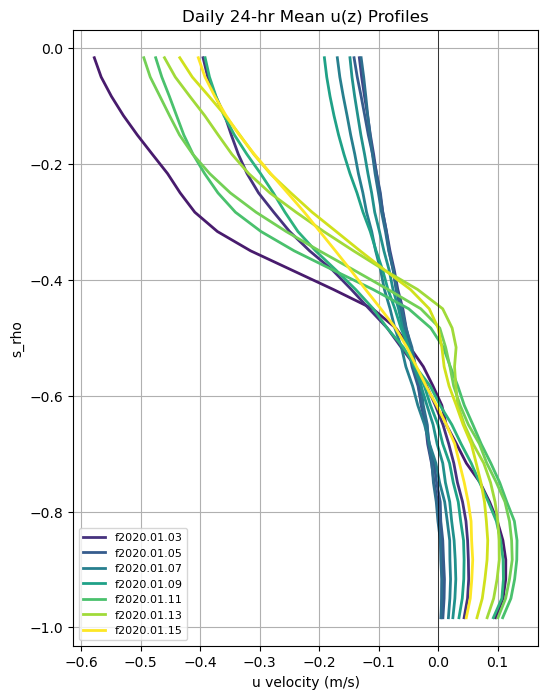

In [ ]:
# average at a fixed grid cell instead of along channel
# xi is i index x direction, eta is j index y direction

base_dir = Path("../../LO_roms/ae0_tgrdnt_xa0/")
day_folders = sorted(base_dir.glob("f2020.01.*"))

# viridis colormap setup
cmap = cm.viridis
norm = colors.Normalize(vmin=0, vmax=len(day_folders)-1)

plt.figure(figsize=(6,8))

handles = []
labels = []

for i, folder in enumerate(day_folders):
    
    if folder.name == "f2020.01.01":
        continue

    flist = sorted(folder.glob("ocean_his_*.nc"))
    if len(flist) == 0:
        continue
    
    ds = xr.open_mfdataset(flist, combine="by_coords")
    ds24 = ds.mean(dim="ocean_time")

    # domain mean u profile
    # u_prof = ds24.u.mean(dim=("eta_u", "xi_u"))
    
    # choose cell in middle
    eta0 = ds24.dims["eta_u"] // 2
    xi0  = ds24.dims["xi_u"] // 2
    u_prof = ds24.u.isel(eta_u=eta0, xi_u=xi0)

    col = cmap(norm(i))

    plt.plot(u_prof.values, ds24.s_rho.values, color=col, lw=2)

    # add to legend 
    if i % 2 == 0:
        handles.append(Line2D([0], [0], color=col, lw=2))
        labels.append(folder.name)

    ds.close()

plt.axvline(0, color='k', lw=0.5)
plt.xlabel("u velocity (m/s)")
plt.ylabel("s_rho")
plt.title("Daily 24-hr Mean u(z) Profiles")
plt.grid(True)

plt.legend(handles, labels, fontsize=8, loc="best")
plt.show()

/tmp/ipykernel_487625/1014882571.py:27: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(flist, combine="by_coords")
/tmp/ipykernel_487625/1014882571.py:31: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  eta0 = ds24.dims["eta_u"] // 2
/tmp/ipykernel_487625/1014882571.py:32: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.di

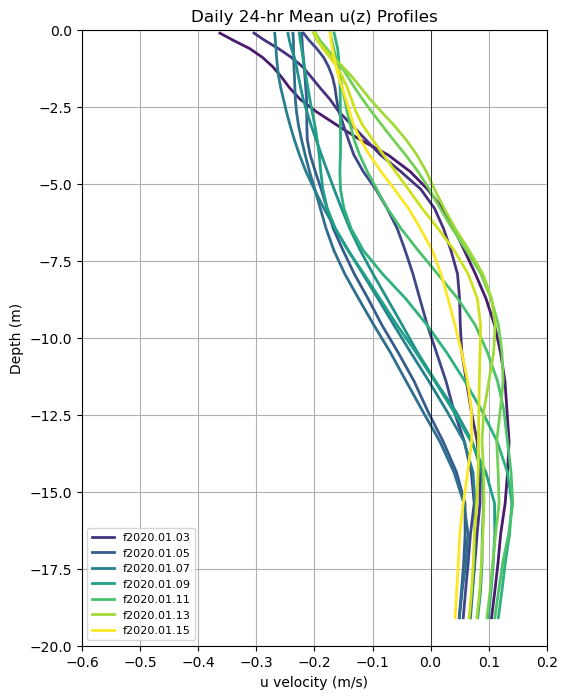

In [4]:
# velocity profile at a point vs depth in meters
base_dir = Path("../../LO_roms/ae0_tgrdnt_xa0lindrag/")
day_folders = sorted(base_dir.glob("f2020.01.*"))

# viridis colormap setup
cmap = cm.viridis
norm = colors.Normalize(vmin=0, vmax=len(day_folders)-1)

plt.figure(figsize=(6,8))

handles = []
labels = []

for i, folder in enumerate(day_folders):
    
    if folder.name == "f2020.01.01":
        continue

    flist = sorted(folder.glob("ocean_his_*.nc"))
    if len(flist) == 0:
        continue
    
    # use first file to get grid info, since all files should be the same
    fn=flist[0]
    G, S, T = zrfun.get_basic_info(fn)
    
    ds = xr.open_mfdataset(flist, combine="by_coords")
    ds24 = ds.mean(dim="ocean_time")
    
    # choose cell in middle
    eta0 = ds24.dims["eta_u"] // 2
    xi0  = ds24.dims["xi_u"] // 3
    u_prof = ds24.u.isel(eta_u=eta0, xi_u=xi0) # velocity profile at u point
    
    # compute z_rho (meters)
    h = G['h']
    zeta = ds24.zeta.values
    z_rho = zrfun.get_z(h, zeta, S, only_rho=True)
    
    # pick matching rho-point depth column
    z_prof = z_rho[:, eta0, xi0]

    col = cmap(norm(i))

    plt.plot(u_prof, z_prof, color=col, lw=2)
    plt.xlim(-0.6,0.2)
    plt.ylim(-20,0)

    # add to legend 
    if i % 2 == 0:
        handles.append(Line2D([0], [0], color=col, lw=2))
        labels.append(folder.name)

    ds.close()

plt.axvline(0, color='k', lw=0.5)
plt.xlabel("u velocity (m/s)")
plt.ylabel("Depth (m)")
plt.title("Daily 24-hr Mean u(z) Profiles")
plt.grid(True)

plt.legend(handles, labels, fontsize=8, loc="lower left")
plt.show()

/tmp/ipykernel_487625/261566462.py:27: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(flist, combine="by_coords")
/tmp/ipykernel_487625/261566462.py:31: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  eta0 = ds24.dims["eta_u"] // 2
/tmp/ipykernel_487625/261566462.py:32: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`

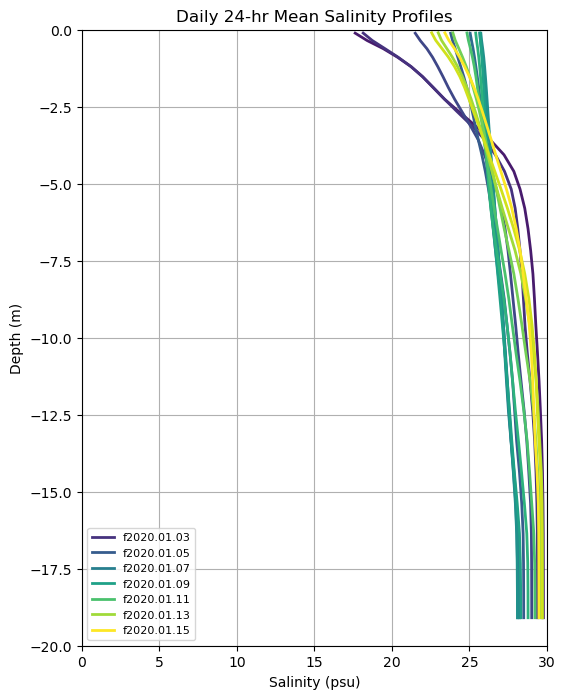

In [6]:
# salinity profile at a point vs depth in meters
base_dir = Path("../../LO_roms/ae0_tgrdnt_xa0lindrag/")
day_folders = sorted(base_dir.glob("f2020.01.*"))

# viridis colormap setup
cmap = cm.viridis
norm = colors.Normalize(vmin=0, vmax=len(day_folders)-1)

plt.figure(figsize=(6,8))

handles = []
labels = []

for i, folder in enumerate(day_folders):
    
    if folder.name == "f2020.01.01":
        continue

    flist = sorted(folder.glob("ocean_his_*.nc"))
    if len(flist) == 0:
        continue
    
    # use first file to get grid info, since all files should be the same
    fn=flist[0]
    G, S, T = zrfun.get_basic_info(fn)
    
    ds = xr.open_mfdataset(flist, combine="by_coords")
    ds24 = ds.mean(dim="ocean_time")
    
    # choose cell in middle
    eta0 = ds24.dims["eta_u"] // 2
    xi0  = ds24.dims["xi_u"] // 3
    
    # u_prof = ds24.u.isel(eta_u=eta0, xi_u=xi0) # velocity profile at u point
    
    salt_prof = ds24.salt.isel(eta_rho=eta0, xi_rho=xi0).values # salinity profile at rho point
    
    # compute z_rho (meters)
    h = G['h']
    zeta = ds24.zeta.values
    z_rho = zrfun.get_z(h, zeta, S, only_rho=True)
    
    # pick matching rho-point depth column
    z_prof = z_rho[:, eta0, xi0]

    col = cmap(norm(i))

    plt.plot(salt_prof, z_prof, color=col, lw=2)
    plt.xlim(0,30)
    plt.ylim(-20,0)

    # add to legend 
    if i % 2 == 0:
        handles.append(Line2D([0], [0], color=col, lw=2))
        labels.append(folder.name)

    ds.close()

plt.axvline(0, color='k', lw=0.5)
plt.xlabel("Salinity (psu)")
plt.ylabel("Depth (m)")
plt.title("Daily 24-hr Mean Salinity Profiles")
plt.grid(True)

plt.legend(handles, labels, fontsize=8, loc="lower left")
plt.show()

/tmp/ipykernel_396473/2764311687.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  eta0 = ds24.dims["eta_u"] // 2
/tmp/ipykernel_396473/2764311687.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  xi0  = ds24.dims["xi_u"] // 3


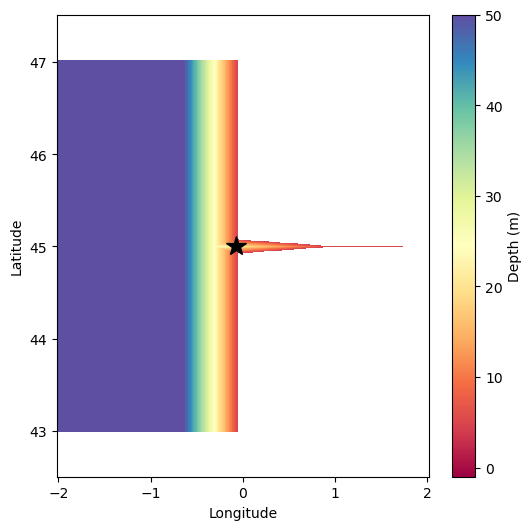

In [91]:
eta0 = ds24.dims["eta_u"] // 2
xi0  = ds24.dims["xi_u"] // 3

# plot chosen cell location on grid (do once)
lon0 = float(ds24.lon_u.isel(eta_u=eta0, xi_u=xi0))
lat0 = float(ds24.lat_u.isel(eta_u=eta0, xi_u=xi0))


plt.figure(figsize=(6,6))
hplot = ds24.h.where(ds24.h > 4)

plt.pcolormesh(ds24.lon_rho, ds24.lat_rho, hplot,
               shading='nearest', cmap='Spectral', vmin=-1, vmax=50)
plt.colorbar(label='Depth (m)')
plt.plot(lon0, lat0, marker='*', color='k', markersize=15)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("equal")
plt.show()

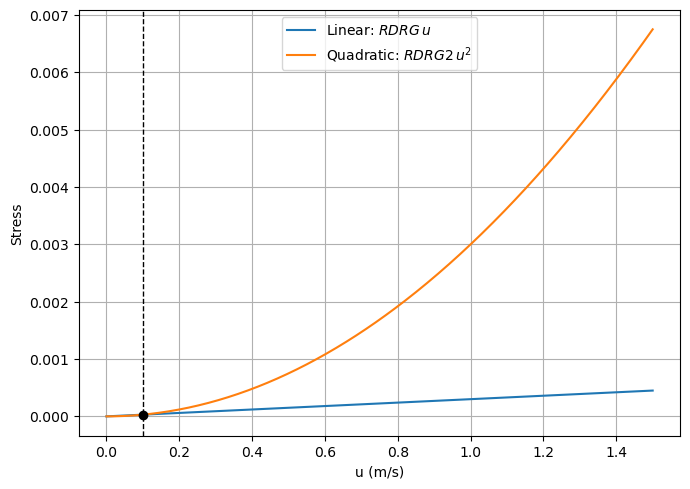

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Drag coefficients
RDRG  = 3.0e-4   # m/s (linear)
RDRG2 = 3.0e-3   # nondimensional (quadratic)

# Velocity range (m/s)
u = np.linspace(0, 1.5, 500)

# Stress per density (tau/rho) forms
linear = RDRG * u
quad   = RDRG2 * u**2

# Crossover speed
u_eq = RDRG / RDRG2
tau_eq = RDRG * u_eq  # same as RDRG2*u_eq**2

plt.figure(figsize=(7,5))
plt.plot(u, linear, label=r"Linear: $RDRG\,u$")
plt.plot(u, quad, label=r"Quadratic: $RDRG2\,u^2$")

# Mark crossover
plt.scatter([u_eq], [tau_eq], zorder=5, color='k')
plt.axvline(u_eq, linestyle="--", linewidth=1, color='k')

plt.xlabel("u (m/s)")
plt.ylabel("Stress")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()